In [1]:
import numpy as np
import pandas as pd
from math import e
np.random.seed(42)
import matplotlib.pyplot as plt

In [2]:
data = {
    'temperature': [10, 15, 20, 25, 30, 35],
    'humidity'   : [30, 40, 50, 60, 70, 80],
    'y'          : [ 0,  0,  1,  1,  1,  0]
}

data

{'temperature': [10, 15, 20, 25, 30, 35],
 'humidity': [30, 40, 50, 60, 70, 80],
 'y': [0, 0, 1, 1, 1, 0]}

In [3]:
df = pd.DataFrame(data)

df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,1
5,35,80,0


In [4]:
mask0 = df['y'] == 0

mask0

0     True
1     True
2    False
3    False
4    False
5     True
Name: y, dtype: bool

In [5]:
df.loc[mask0, 'temperature']

0    10
1    15
5    35
Name: temperature, dtype: int64

In [6]:
df.loc[mask0, 'humidity']

0    30
1    40
5    80
Name: humidity, dtype: int64

In [7]:
mask1 = df['y'] == 1

mask1

0    False
1    False
2     True
3     True
4     True
5    False
Name: y, dtype: bool

In [8]:
df.loc[mask1, 'temperature']

2    20
3    25
4    30
Name: temperature, dtype: int64

In [9]:
df['temperature']

0    10
1    15
2    20
3    25
4    30
5    35
Name: temperature, dtype: int64

In [10]:
df['humidity']

0    30
1    40
2    50
3    60
4    70
5    80
Name: humidity, dtype: int64

In [11]:
df['y']

0    0
1    0
2    1
3    1
4    1
5    0
Name: y, dtype: int64

In [12]:
list(zip(df['temperature'], df['humidity'], df['y']))

[(10, 30, 0), (15, 40, 0), (20, 50, 1), (25, 60, 1), (30, 70, 1), (35, 80, 0)]

In [13]:
print('=' * 30)
for temp, hum, yv in zip(df['temperature'], df['humidity'], df['y']):
    print(f'temp = {temp}, hum = {hum}, yv = {yv}')
    print('=' * 30)

temp = 10, hum = 30, yv = 0
temp = 15, hum = 40, yv = 0
temp = 20, hum = 50, yv = 1
temp = 25, hum = 60, yv = 1
temp = 30, hum = 70, yv = 1
temp = 35, hum = 80, yv = 0


In [14]:
df.loc[mask1, 'humidity']

2    50
3    60
4    70
Name: humidity, dtype: int64

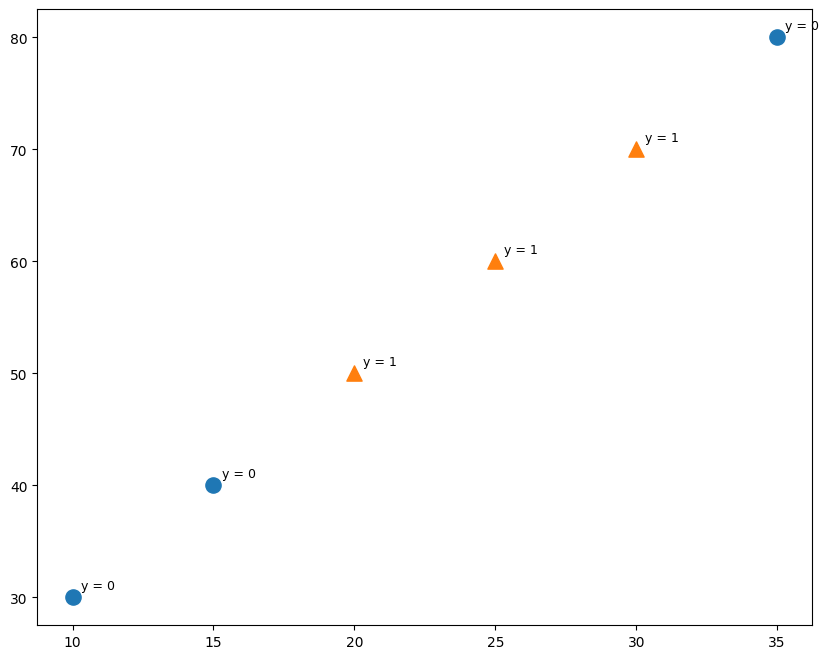

In [15]:
plt.figure(figsize = (10, 8))
plt.scatter(x = df.loc[mask0, 'temperature'], y = df.loc[mask0, 'humidity'], s = 120, label = 'y = 0')
plt.scatter(
    x = df.loc[mask1, 'temperature'], y = df.loc[mask1, 'humidity'], s = 120, label = 'y = 1', marker = '^'
    )

for temp, hum, yv in zip(df['temperature'], df['humidity'], df['y']):
    plt.annotate(text = f'y = {yv}', xy = (temp, hum), fontsize = 9, 
                 textcoords = 'offset points', xytext = (6, 6))

In [16]:
X_raw = df[['temperature', 'humidity']].to_numpy(dtype = float)

X_raw

array([[10., 30.],
       [15., 40.],
       [20., 50.],
       [25., 60.],
       [30., 70.],
       [35., 80.]])

In [17]:
y = df['y'].to_numpy(dtype = float).reshape(-1, 1)

y

array([[0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.]])

In [18]:
X_mean = X_raw.mean(axis = 0, keepdims = True)

X_mean

array([[22.5, 55. ]])

In [19]:
X_std = X_raw.std(axis = 0, keepdims = True)

X_std

array([[ 8.53912564, 17.07825128]])

In [20]:
X_norm = (X_raw - X_mean) / X_std

X_norm

array([[-1.46385011, -1.46385011],
       [-0.87831007, -0.87831007],
       [-0.29277002, -0.29277002],
       [ 0.29277002,  0.29277002],
       [ 0.87831007,  0.87831007],
       [ 1.46385011,  1.46385011]])

In [21]:
df['temperature_norm'] = X_norm[:, 0]
df['humidity_norm'] = X_norm[:, 1]

df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,1,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [ ]:
def sigmoid(H):
    H_clip = np.clip(H, -500, 500)
    
    z = 1.0 / (1.0 + e ** (-H_clip))
    return z